# Sampling, Uncertainty, and Confidence Intervals

This notebook shows:

1. A **population** of 10,000 values  
2. A **sample mean** compared with the true population mean  
3. **Sampling variability** across repeated samples  
4. The effect of **sample size** on variability  
5. **Confidence intervals** for small vs large samples  


## 1. Create a Population

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

# Create a population of 10,000 values
population = np.random.normal(loc=50, scale=10, size=10000)

population_mean = population.mean()
population_std = population.std()

print("Population mean:", round(population_mean, 3))
print("Population std:", round(population_std, 3))

Population mean: 49.979
Population std: 10.034


## 2. Take One Sample and Compare Means

In [ ]:
sample = np.random.choice(population, size=50, replace=False)
sample_mean = sample.mean()

print("Population mean:", round(population_mean, 3))
print("Sample mean:", round(sample_mean, 3))
print("Difference:", round(sample_mean - population_mean, 3))

Population mean: 49.979
Sample mean: 50.592
Difference: 0.613


## 3. Repeated Sampling: Same Sample Size

In [ ]:
sample_means_50 = []

for _ in range(200):
    s = np.random.choice(population, size=50, replace=False)
    sample_means_50.append(s.mean())

sample_means_50[:10]

[np.float64(49.25540388037188),
 np.float64(50.42875367951024),
 np.float64(49.928632779627115),
 np.float64(49.996797466435304),
 np.float64(49.85903159610095),
 np.float64(48.953650780555684),
 np.float64(49.58301355706002),
 np.float64(53.13017034370861),
 np.float64(50.59715409018064),
 np.float64(51.42560642283722)]

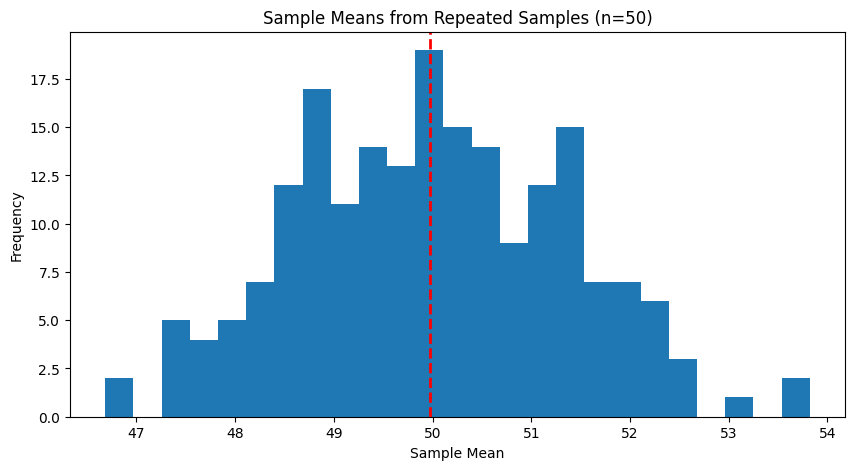

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(sample_means_50, bins=25)
plt.axvline(population_mean, linestyle='--', linewidth=2, color="red")
plt.title("Sample Means from Repeated Samples (n=50)")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.show()

## 4. Sampling Variability: Small vs Large Samples

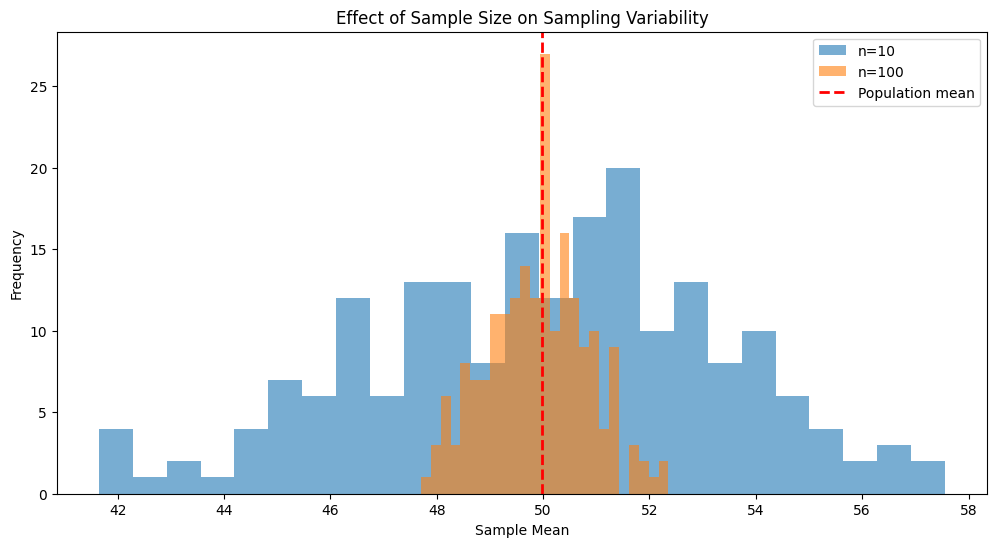

In [ ]:
sample_means_10 = []
sample_means_100 = []

for _ in range(200):
    s_small = np.random.choice(population, size=10, replace=False)
    s_large = np.random.choice(population, size=100, replace=False)
    sample_means_10.append(s_small.mean())
    sample_means_100.append(s_large.mean())

plt.figure(figsize=(12, 6))
plt.hist(sample_means_10, bins=25, alpha=0.6, label="n=10")
plt.hist(sample_means_100, bins=25, alpha=0.6, label="n=100")
plt.axvline(population_mean, linestyle='--', linewidth=2, label="Population mean", color="red")
plt.title("Effect of Sample Size on Sampling Variability")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [ ]:
print("Std of sample means (n=10):", round(np.std(sample_means_10), 3))
print("Std of sample means (n=100):", round(np.std(sample_means_100), 3))

Std of sample means (n=10): 3.291
Std of sample means (n=100): 0.934


## 5. One Confidence Interval

In [ ]:
sample = np.random.choice(population, size=50, replace=False)
mean = sample.mean()
std = sample.std(ddof=1)
n = len(sample)

margin = stats.t.ppf(0.975, df=n-1) * (std / np.sqrt(n))
ci_low, ci_high = mean - margin, mean + margin

print("Sample mean:", round(mean, 3))
print("95% CI:", (round(ci_low, 3), round(ci_high, 3)))
print("Population mean:", round(population_mean, 3))

Sample mean: 51.237
95% CI: (np.float64(48.519), np.float64(53.956))
Population mean: 49.979


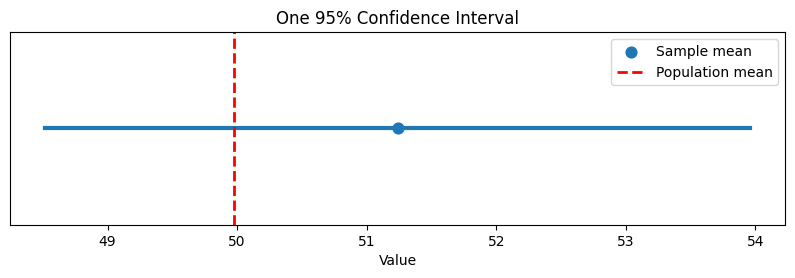

In [ ]:
plt.figure(figsize=(10, 2.5))
plt.plot([ci_low, ci_high], [0, 0], linewidth=3)
plt.scatter(mean, 0, s=60, label="Sample mean")
plt.axvline(population_mean, linestyle='--', linewidth=2, label="Population mean", color="red")
plt.yticks([])
plt.xlabel("Value")
plt.title("One 95% Confidence Interval")
plt.legend()
plt.show()

## 6. Confidence Intervals: Small vs Large Samples

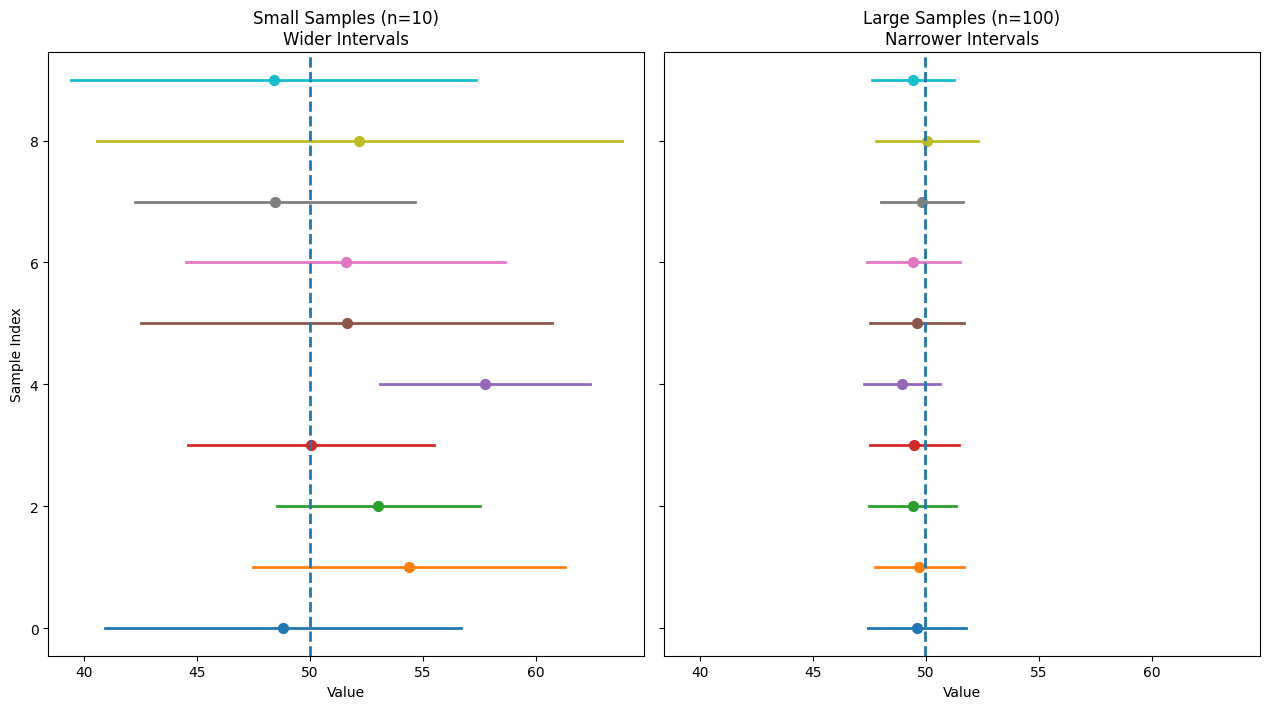

In [ ]:
np.random.seed(7)

num_samples = 10
means_small, lows_small, highs_small = [], [], []
means_large, lows_large, highs_large = [], [], []

for _ in range(num_samples):
    # small sample
    s1 = np.random.choice(population, size=10, replace=False)
    m1 = s1.mean()
    sd1 = s1.std(ddof=1)
    me1 = stats.t.ppf(0.975, df=9) * (sd1 / np.sqrt(10))
    means_small.append(m1)
    lows_small.append(m1 - me1)
    highs_small.append(m1 + me1)

    # large sample
    s2 = np.random.choice(population, size=100, replace=False)
    m2 = s2.mean()
    sd2 = s2.std(ddof=1)
    me2 = stats.t.ppf(0.975, df=99) * (sd2 / np.sqrt(100))
    means_large.append(m2)
    lows_large.append(m2 - me2)
    highs_large.append(m2 + me2)

all_x = np.concatenate([lows_small, highs_small, lows_large, highs_large])
xmin, xmax = all_x.min() - 1, all_x.max() + 1

fig, axes = plt.subplots(1, 2, figsize=(12.8, 7.2), sharey=True)

for i in range(num_samples):
    axes[0].plot([lows_small[i], highs_small[i]], [i, i], linewidth=2)
    axes[0].scatter(means_small[i], i, s=50)
axes[0].axvline(population_mean, linestyle='--', linewidth=2)
axes[0].set_xlim(xmin, xmax)
axes[0].set_title("Small Samples (n=10)\nWider Intervals")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Sample Index")

for i in range(num_samples):
    axes[1].plot([lows_large[i], highs_large[i]], [i, i], linewidth=2)
    axes[1].scatter(means_large[i], i, s=50)
axes[1].axvline(population_mean, linestyle='--', linewidth=2)
axes[1].set_xlim(xmin, xmax)
axes[1].set_title("Large Samples (n=100)\nNarrower Intervals")
axes[1].set_xlabel("Value")

plt.tight_layout()
plt.show()

## 7. Key Takeaway

- Different samples give different estimates  
- Larger samples produce **less variability** in sample means  
- Larger samples also produce **narrower confidence intervals**  
- Confidence intervals help express uncertainty around estimates  
